In [ ]:
#Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import ast
import seaborn as sns
from datasets import load_dataset

#Loading Data
df = load_dataset('Lukebarousse/data_jobs')
df = df['train']
df = df.to_pandas()

#Data Cleanup
df['job_posted_date'] = pd.to_datetime(df.job_posted_date)
df['job_skills'] = df.job_skills.apply(lambda skill: ast.literal_eval(skill) if pd.notna(skill) else skill)

In [47]:
#Filtering the jobs for jobs in US
df_US = df[df['job_country'] == 'United States'].dropna(subset='salary_year_avg')

In [48]:
job_titles = df_US['job_title_short'].value_counts().index[:6].tolist()

In [49]:
df_US_top6 = df_US[df_US['job_title_short'].isin(job_titles)]

In [55]:
job_order = df_US_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

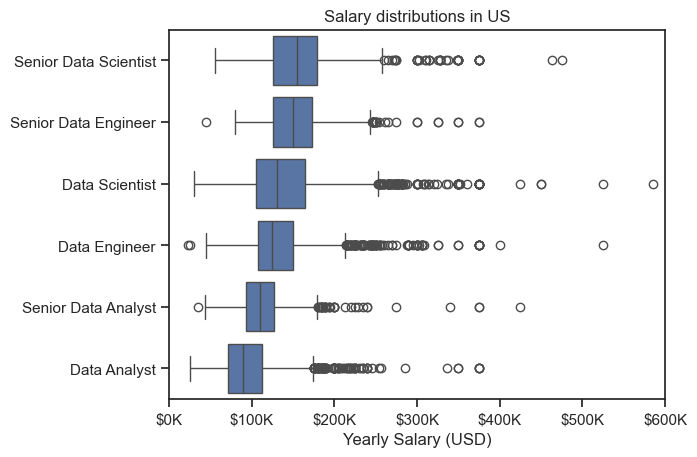

In [56]:
sns.boxplot(df_US_top6, x = 'salary_year_avg', y = 'job_title_short', order = job_order)
sns.set_theme(style='ticks')

plt.title('Salary distributions in US')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
ticks_x = plt.FuncFormatter(lambda x, pos: f"${int(x/1000)}K")
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.xlim(0, 600_000)
plt.show()

### Inverstigate Median Salary Vs Skill for Data Analysts

In [58]:
df_DA_IND = df[(df['job_title_short'] == 'Data Analyst') & (df['job_country'] == 'India')].copy()

df_DA_IND = df_DA_IND.dropna(subset=['salary_year_avg'])

In [60]:
df_DA_IND = df_DA_IND.explode('job_skills')

In [66]:
df_DA_IND_topPay = df_DA_IND.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values('median', ascending=False).head(10)

In [75]:
df_DA_IND_skills = df_DA_IND.groupby('job_skills')['salary_year_avg'].agg(['count', 'median']).sort_values('count', ascending=False).head(10)

df_Da_IND_skills = df_DA_IND_skills.sort_values('median', ascending=False)

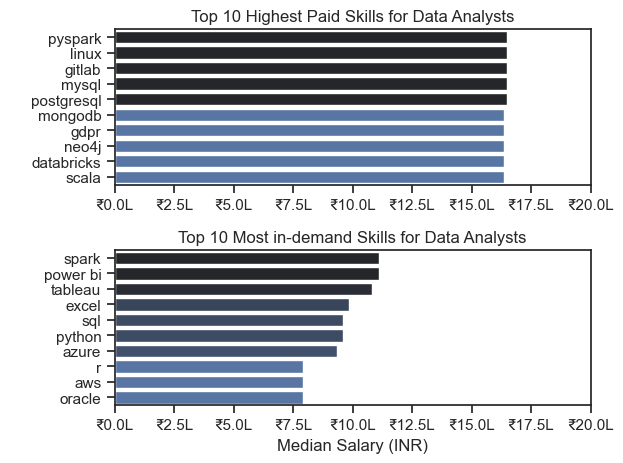

In [97]:
fig, ax = plt.subplots(2, 1)
sns.set_theme(style='ticks')
sns.barplot(data=df_DA_IND_topPay, x='median', y=df_DA_IND_topPay.index, ax=ax[0], hue='median', palette='dark:b_r')
ax[0].set_ylabel(' ')
ax[0].set_title('Top 10 Highest Paid Skills for Data Analysts')
ax[0].set_xlim(0, 200_000)
ax[0].set_xlabel('')
ax[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"₹{x/10000:.1f}L"))
ax[0].legend().remove()

sns.barplot(data=df_Da_IND_skills, x='median', y=df_Da_IND_skills.index, ax=ax[1], hue='median', palette='dark:b_r')
ax[1].set_ylabel(' ')
ax[1].set_title('Top 10 Most in-demand Skills for Data Analysts')
ax[1].set_xlim(0, 200_000)
ax[1].set_xlabel('Median Salary (INR)')
ax[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: f"₹{x/10000:.1f}L"))
ax[1].legend().remove()

fig.tight_layout()
plt.show()